In [6]:
# pandas helps us work with tables and data
import pandas as pd

# numpy helps us do math operations
import numpy as np

# matplotlib and seaborn help us draw charts
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn helps us build the prediction model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
df = pd.read_csv(r'C:\Users\Ekiaby\Downloads\netflix_titles.csv.zip')
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
# Check how many rows and columns we have
print(f'Number of rows   : {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows   : 8807
Number of columns: 12


In [11]:
# Show all column names
print('Column names:')
print(df.columns.tolist())

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [12]:
print('Data types of each column:')
print(df.dtypes)

Data types of each column:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [13]:
# What does each column mean?
print("""
Column descriptions:
   show_id      : A unique ID for each movie or show
   type         : Movie or TV Show
   title        : The name of the movie or show
   director     : Who directed it
   cast         : The actors in it
   country      : Which country made it
   date_added   : When it was added to Netflix
   release_year : When it was originally released
   rating       : Age rating (TV-MA, PG-13, etc.)
   duration     : Length in minutes (movies) or seasons (shows)
   listed_in    : Genre (Action, Comedy, etc.)
   description  : A short summary of the content
""")


Column descriptions:
   show_id      : A unique ID for each movie or show
   type         : Movie or TV Show
   title        : The name of the movie or show
   director     : Who directed it
   cast         : The actors in it
   country      : Which country made it
   date_added   : When it was added to Netflix
   release_year : When it was originally released
   rating       : Age rating (TV-MA, PG-13, etc.)
   duration     : Length in minutes (movies) or seasons (shows)
   listed_in    : Genre (Action, Comedy, etc.)
   description  : A short summary of the content



In [14]:
print('Basic statistics:')
df.describe()

Basic statistics:


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [15]:
print('Number of missing values in each column:')
print(df.isnull().sum())

Number of missing values in each column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')

df = df.dropna(subset=['date_added', 'rating', 'duration'])

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [ ]:
df['date_added'] = df['date_added'].str.strip()
df['year_added'] = df['date_added'].str[-4:]
df['year_added'] = pd.to_numeric(df['year_added'], errors='coerce')

df['duration_mins'] = df.apply(
    lambda row: int(row['duration'].split(' ')[0]) if 'min' in str(row['duration']) else None,
    axis=1
)

print(f'Dataset size after cleaning: {df.shape[0]} rows and {df.shape[1]} columns')
df[['title', 'type', 'country', 'year_added', 'duration_mins']].head()

Dataset size after cleaning: 8790 rows and 14 columns


,title,type,country,year_added,duration_mins
0,Dick Johnson Is Dead,Movie,United States,2021,90.0
1,Blood & Water,TV Show,South Africa,2021,NaN
2,Ganglands,TV Show,Unknown,2021,NaN
3,Jailbirds New Orleans,TV Show,Unknown,2021,NaN
4,Kota Factory,TV Show,India,2021,NaN


In [18]:
# How many movies and how many TV shows?
print('Count of Movies vs TV Shows:')
print(df['type'].value_counts())

Count of Movies vs TV Shows:
Movie      6126
TV Show    2664
Name: type, dtype: int64


In [19]:
# Which countries produce the most content?
print('Top 10 countries by content:')
top_countries = df['country'].str.split(',').explode().str.strip()
print(top_countries.value_counts().head(10))

Top 10 countries by content:
United States     3681
India             1046
Unknown            829
United Kingdom     805
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Name: country, dtype: int64


In [20]:
# What are the most common age ratings?
print('Most common age ratings:')
print(df['rating'].value_counts().head(8))

Most common age ratings:
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
Name: rating, dtype: int64


In [21]:
# How much content was added to Netflix each year?
print('Content added per year:')
print(df['year_added'].value_counts().sort_index())

Content added per year:
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: year_added, dtype: int64


In [22]:
# Movie duration statistics
movies_df = df[df['type'] == 'Movie'].copy()

print('Movie duration statistics (in minutes):')
print(f'   Shortest movie : {movies_df["duration_mins"].min()} minutes')
print(f'   Longest movie  : {movies_df["duration_mins"].max()} minutes')
print(f'   Average length : {movies_df["duration_mins"].mean():.1f} minutes')

Movie duration statistics (in minutes):
   Shortest movie : 3.0 minutes
   Longest movie  : 312.0 minutes
   Average length : 99.6 minutes


In [23]:
# Which years had the most content released?
print('Top 10 release years:')
print(df['release_year'].value_counts().head(10))

Top 10 release years:
2018    1146
2017    1030
2019    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: release_year, dtype: int64


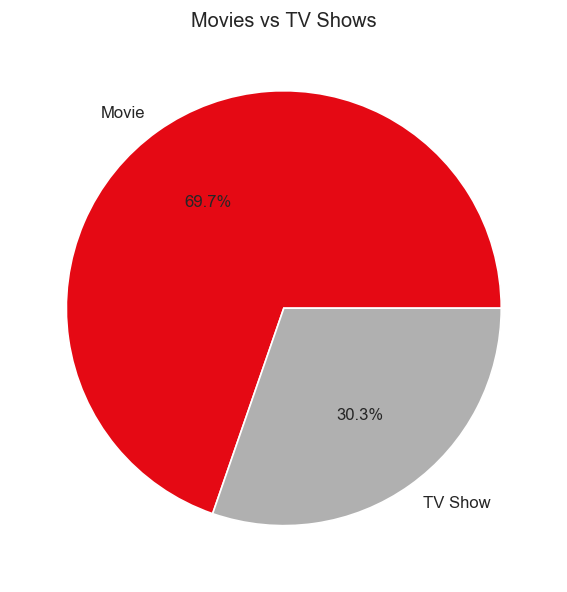

In [26]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['#E50914', '#b0b0b0']
)
plt.title('Movies vs TV Shows')
plt.show()

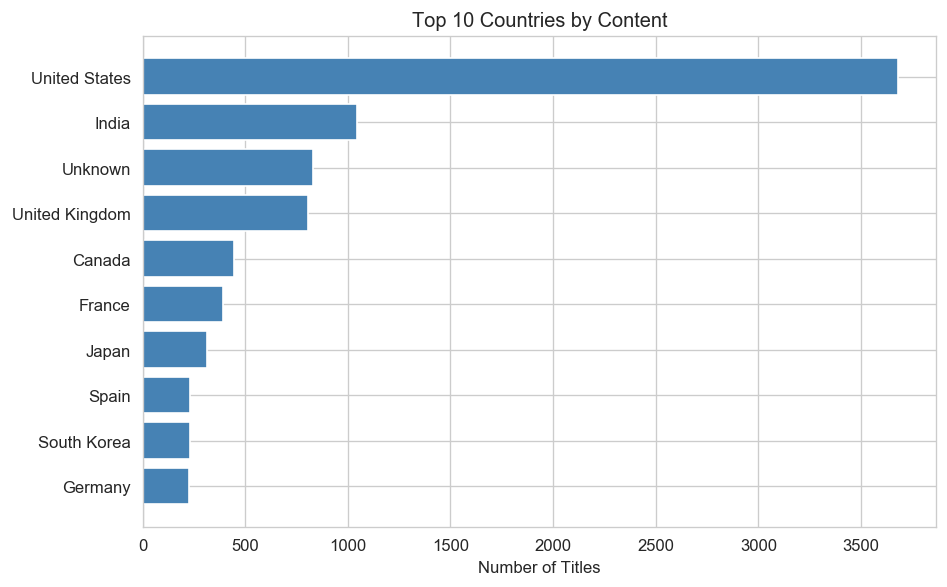

In [27]:
# Chart 2: Top 10 Countries by Content
top_c = df['country'].str.split(',').explode().str.strip().value_counts().head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_c.index[::-1], top_c.values[::-1], color='steelblue')
plt.title('Top 10 Countries by Content')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()

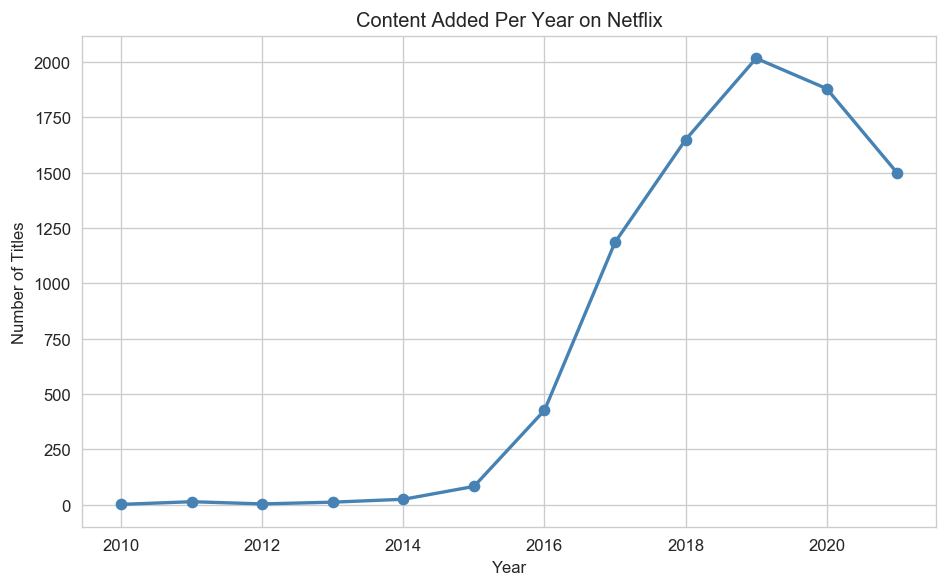

In [28]:
# Chart 3: Content Added Per Year on Netflix
yearly = df[df['year_added'] >= 2010]['year_added'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(yearly.index, yearly.values, marker='o', color='steelblue', linewidth=2)
plt.title('Content Added Per Year on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

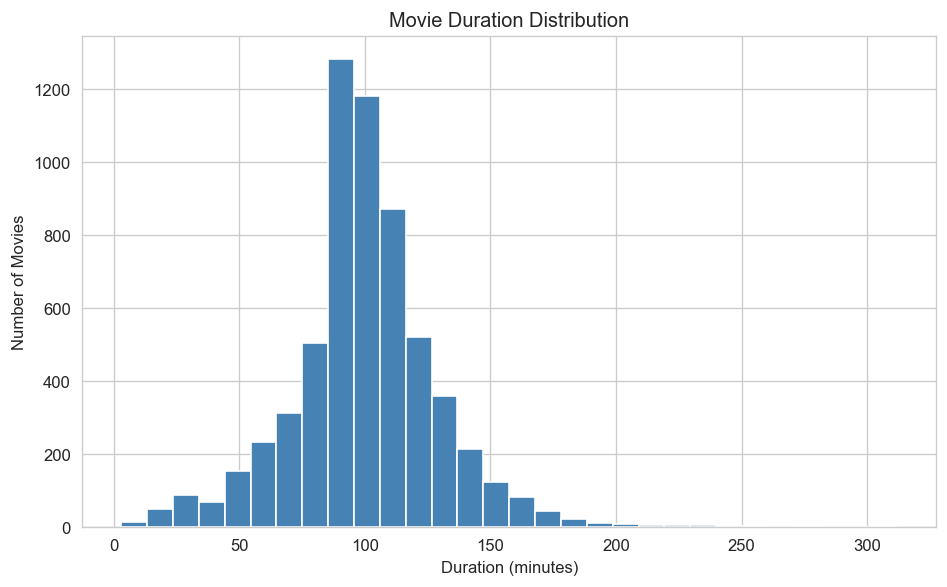

In [29]:
# Chart 4: Movie Duration Distribution
movies_clean = df[df['type'] == 'Movie'].dropna(subset=['duration_mins'])

plt.figure(figsize=(8, 5))
plt.hist(movies_clean['duration_mins'], bins=30, color='steelblue', edgecolor='white')
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

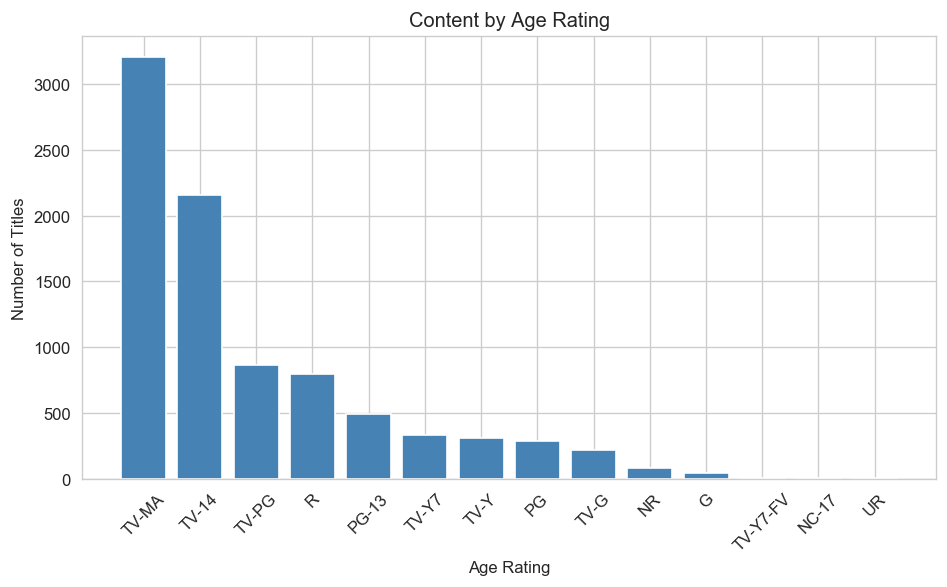

In [30]:
# Chart 5: Content by Age Rating
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')
plt.title('Content by Age Rating')
plt.xlabel('Age Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
print('Goal: predict if the content is a Movie or a TV Show')
print('Using: release year, year added, and age rating')

# Step 1: Select the columns we need
model_df = df[['type', 'release_year', 'year_added', 'rating']].dropna().copy()

print(f'Total examples: {len(model_df)}')

Goal: predict if the content is a Movie or a TV Show
Using: release year, year added, and age rating
Total examples: 8790


In [32]:
# Step 2: Convert text to numbers
# Machine learning models only understand numbers, not words

le_type   = LabelEncoder()
le_rating = LabelEncoder()

model_df['type_encoded']   = le_type.fit_transform(model_df['type'])
model_df['rating_encoded'] = le_rating.fit_transform(model_df['rating'])

print('Text converted to numbers:')
model_df[['type', 'type_encoded', 'rating', 'rating_encoded']].head()

Text converted to numbers:


,type,type_encoded,rating,rating_encoded
0,Movie,0,PG-13,4
1,TV Show,1,TV-MA,8
2,TV Show,1,TV-MA,8
3,TV Show,1,TV-MA,8
4,TV Show,1,TV-MA,8


In [33]:
# Step 3: Define inputs (X) and output (y)
# X = what the model uses to predict
# y = what we want the model to predict

X = model_df[['release_year', 'year_added', 'rating_encoded']]
y = model_df['type_encoded']

print(f'Movie examples  : {(y == 0).sum()}')
print(f'TV Show examples: {(y == 1).sum()}')

Movie examples  : 6126
TV Show examples: 2664


In [34]:
# Step 4: Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Training examples: {len(X_train)}')
print(f'Testing examples : {len(X_test)}')

Training examples: 7032
Testing examples : 1758


In [35]:
# Step 5: Create and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print('Model trained successfully!')

Model trained successfully!


In [36]:
# Step 6: Test the model and check accuracy
y_pred   = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Model Accuracy: {accuracy * 100:.2f}%')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred, target_names=le_type.classes_))

Model Accuracy: 70.88%

Detailed Report:
              precision    recall  f1-score   support

       Movie       0.72      0.96      0.82      1227
     TV Show       0.59      0.12      0.19       531

    accuracy                           0.71      1758
   macro avg       0.65      0.54      0.51      1758
weighted avg       0.68      0.71      0.63      1758



In [ ]:
new_example = pd.DataFrame({
    'release_year':   [2020],
    'year_added':     [2021],
    'rating_encoded': [le_rating.transform(['TV-MA'])[0]]
})

prediction = model.predict(new_example)

print('Input : release_year=2020, year_added=2021, rating=TV-MA')
print(f'Output: {le_type.inverse_transform(prediction)[0]}')

Input : release_year=2020, year_added=2021, rating=TV-MA
Output: Movie


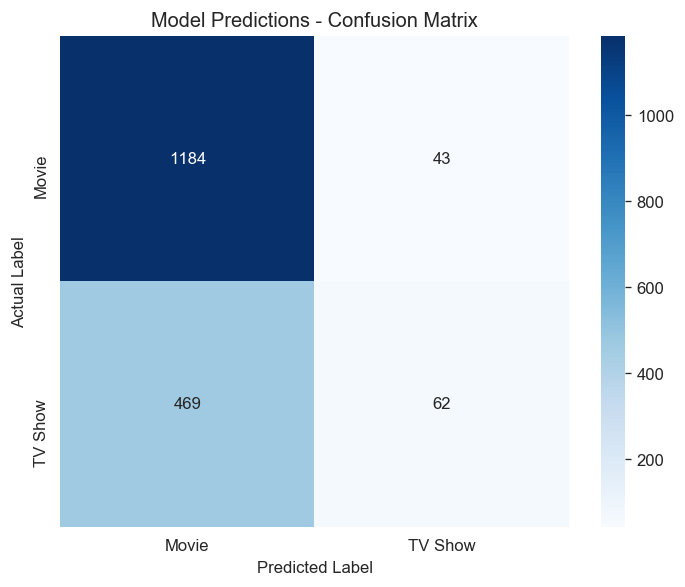

In [ ]:
# First, we need to import confusion_matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Get the predictions from the model
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
# Draw the chart
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,          
    fmt='d',             
    cmap='Blues',        
    xticklabels=le_type.classes_,
    yticklabels=le_type.classes_
)
plt.title('Model Predictions - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()